In [57]:
!pip install xmltodict geopandas==1.1 numpy==1.26.4 shapely contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.6/114.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 23.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 6.3 MB/s eta 0:00:00


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.axisbelow'] = True
plt.rcParams['figure.dpi'] = 150

In [2]:
# Check available hardware
import torch
if torch.cuda.is_available():
    print(f'GPU is available, using GPU {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
elif torch.mps.is_available():
    print(f'Apple Metal Performance Shaders framework is available, using {torch.device("mps")}')
    device = torch.device('mps')
else:
    print(f'Hardware acceleration not available, using CPU')
    device = torch.device('cpu')

GPU is available, using GPU Tesla T4


In [48]:
config = {
    "HRBT": {
        "bounding_boxes": [
            [-76.3279, 37.0122, -76.2954, 36.9664],
            [-76.3206, 37.0000, -76.2954, 36.9664]
        ]
    },
    "MMBT": {
        "bounding_boxes": [
            [-76.45, 36.8, -76.35, 37.0]
        ]
    },
    "Fredericksburg" : {
        "bounding_boxes": [
            [-77.5940, 38.3724, -77.4026, 37.8982]
        ],
        "target_sensors": [
            "9385011979-0",
            "9385011979-1",
            "9385011979-2"
        ]
    }
}

In [235]:
import requests
import xmltodict
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely import box
from datetime import date, time, datetime

url = "https://data.511-atis-ttrip-prod.iteriscloud.com/smarterRoads/trafficSensor/detectorTMDD/current/trafficSensor_tmdd.xml?token=%242b%2410%24N%2FYVSDe.cOJFuEhCXEV4UuZogMpl7P.0s34ySk%2Fx40HfYIxI.CpH6"
response = requests.get(url)
xml_response = response.content.decode()
try:
    stations = xmltodict.parse(xml_response)['orci:stationList']['orci:station']
except Exception as e:
    print(e)
    print(url)

def get_stations(stations, bbox=None):
    # Adds geometry to each entry for GeoPandas
    headers = []
    for station in stations:
        header = station['orci:inventory']['detector-station-inventory-header']
        lat = int(header['device-location']['latitude']) / 1e6
        lon = int(header['device-location']['longitude']) / 1e6

        info = {
            'device-id': header['device-id'],
            'link-name': header['link-name'],
            # 'link-direction': header['link-direction'],
            'linear-reference': float(header['linear-reference']),
            'last-update': datetime.combine(
                datetime.strptime(header['last-update-time']['date'], '%Y%m%d').date(),
                datetime.strptime(header['last-update-time']['time'], '%H%M%S').time(),
            ),
            'latitude': lat,
            'longitude': lon,
            'geometry': Point(lon, lat),
        }
        # if info['last-update'].date() != datetime.today().date():
        #     continue
        
            
        headers.append(info)

    station_df = gpd.GeoDataFrame(headers, geometry='geometry', crs='EPSG:4326')
    station_df = station_df[station_df['last-update'].dt.date == datetime.today().date()]
    if bbox:
        station_df = station_df[station_df.geometry.within(bbox)]

    return [stations[ii] for ii in station_df.index], station_df

stations, station_df = get_stations(stations, box(*config['Fredericksburg']['bounding_boxes'][0]))
station_df

,device-id,link-name,linear-reference,last-update,latitude,longitude,geometry
158,OpenTMS-Detector400141,I-95N,108.1,2026-10-02 21:30:00,37.983110,-77.492290,POINT (-77.49229 37.98311)
184,OpenTMS-Detector4941727806,I-95N,116.3,2026-10-02 21:30:00,38.099400,-77.517236,POINT (-77.51724 38.0994)
185,OpenTMS-Detector4941750609,I-95N,117.0,2026-10-02 21:30:00,38.109775,-77.517656,POINT (-77.51766 38.10978)
186,OpenTMS-Detector4941779071,I-95N,119.3,2026-10-02 21:30:00,38.141286,-77.506697,POINT (-77.5067 38.14129)
187,OpenTMS-Detector4941826617,I-95N,120.7,2026-10-02 21:30:00,38.161432,-77.507112,POINT (-77.50711 38.16143)
188,OpenTMS-Detector4941836364,I-95N,121.3,2026-10-02 21:30:00,38.170456,-77.503586,POINT (-77.50359 38.17046)
189,OpenTMS-Detector4941846094,I-95N,121.9,2026-10-02 21:30:00,38.178028,-77.501625,POINT (-77.50162 38.17803)
190,OpenTMS-Detector4941879766,I-95N,123.4,2026-10-02 21:30:00,38.199519,-77.499550,POINT (-77.49955 38.19952)
191,OpenTMS-Detector4941908785,I-95N,124.4,2026-10-02 21:30:00,38.215306,-77.498200,POINT (-77.4982 38.21531)
192,OpenTMS-Detector4941942550,I-95N,126.2,2026-10-02 21:30:00,38.240356,-77.499733,POINT (-77.49973 38.24036)


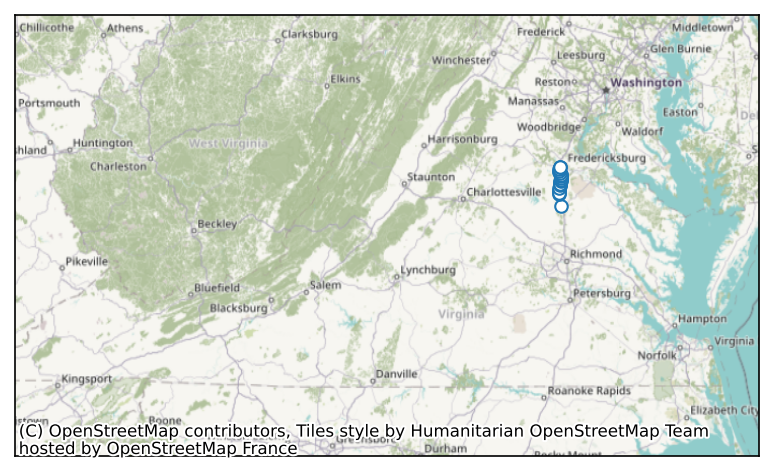

In [237]:
import contextily as cx
ax = plt.figure().gca()
station_df.plot(ax=ax, marker='o', facecolor='white', edgecolor='tab:blue')
ax.set(xlim=[-83, -75.5], ylim=[36, 39.5])
cx.add_basemap(ax=ax, crs=station_df.crs)
ax.set(xticks=[], yticks=[])
ax.grid(False)

In [238]:
import requests
import xmltodict
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely import box

def load_sensor_data(stations, station_df):
    output = []
    for (_, row), station in zip(station_df.iterrows(), stations):
        detector_info = station['orci:inventory']['detector-list']['detector']
        detector_data = station['orci:data']['detector-list']['detector-data-detail']

        for info, data in zip(detector_info, detector_data):
            try:
                output.append({
                    'device-id': row['device-id'],
                    'device-name': info['detector-inventory-header']['device-name'],
                    'detector-id': data['detector-id'],
                    'time': data['detection-time-stamp']['qfree:dateTimeHolder']['qfree:iso-8601'],
                    'lane': info['detection-lanes']['lanes'],
                    'link-direction': info['detector-inventory-header']['link-direction'],
                    'vehicle_count': float(data['vehicle-count']),
                    'vehicle_speed': float(data['vehicle-speed']),
                    'vehicle_occupancy': float(data['vehicle-occupancy']),
                })
            except:
                continue
    df = pd.DataFrame(output)
    df['time'] = pd.to_datetime(df['time']).dt.tz_convert('America/New_York')
    return df

sensor_data = load_sensor_data(stations, station_df)
sensor_data.head(20)

,device-id,device-name,detector-id,time,lane,link-direction,vehicle_count,vehicle_speed,vehicle_occupancy
0,OpenTMS-Detector400141,On Ramp from Rest Area,OpenTMS-Detector400141-1,2026-10-02 17:30:00-04:00,1,n,9.0,40.0,1.0
1,OpenTMS-Detector400141,NB Right Lane,OpenTMS-Detector400141-2,2026-10-02 17:30:00-04:00,2,n,44.0,66.0,3.0
2,OpenTMS-Detector400141,NB Middle Lane,OpenTMS-Detector400141-3,2026-10-02 17:30:00-04:00,3,n,112.0,68.0,10.0
3,OpenTMS-Detector400141,NB Left Lane,OpenTMS-Detector400141-4,2026-10-02 17:30:00-04:00,4,n,135.0,70.0,9.0
4,OpenTMS-Detector400141,SB Left Lane,OpenTMS-Detector400141-5,2026-10-02 17:30:00-04:00,3,s,40.0,72.0,2.0
5,OpenTMS-Detector400141,SB Middle Lane,OpenTMS-Detector400141-6,2026-10-02 17:30:00-04:00,2,s,72.0,70.0,4.0
6,OpenTMS-Detector400141,SB Right Lane,OpenTMS-Detector400141-7,2026-10-02 17:30:00-04:00,1,s,46.0,66.0,4.0
7,OpenTMS-Detector4941727806,Lane1,OpenTMS-Detector4941727806-0,2026-10-02 17:30:00-04:00,1,n,76.0,71.0,8.0
8,OpenTMS-Detector4941727806,Lane2,OpenTMS-Detector4941727806-1,2026-10-02 17:30:00-04:00,2,n,120.0,74.0,10.0
9,OpenTMS-Detector4941727806,Lane3,OpenTMS-Detector4941727806-2,2026-10-02 17:30:00-04:00,3,n,144.0,78.0,9.0


In [239]:
gdf = station_df.merge(sensor_data, on='device-id', how='right')
gdf = gdf.set_index(['link-direction', 'lane', 'device-id']).sort_index()
gdf

link-name  linear-reference  \
link-direction lane device-id                                                
n              1    OpenTMS-Detector400141         I-95N             108.1   
                    OpenTMS-Detector4941664956     I-95N             115.0   
                    OpenTMS-Detector4941701029     I-95N             115.5   
                    OpenTMS-Detector4941727806     I-95N             116.3   
                    OpenTMS-Detector4941750609     I-95N             117.0   
...                                                  ...               ...   
               3    OpenTMS-Detector9385011979     I-95N             130.5   
               4    OpenTMS-Detector400141         I-95N             108.1   
s              1    OpenTMS-Detector400141         I-95N             108.1   
               2    OpenTMS-Detector400141         I-95N             108.1   
               3    OpenTMS-Detector400141         I-95N             108.1   

                                                       last-update   latitude  \
link-direction lane device-id                                                   
n              1    OpenTMS-Detector400141     2026-10-02 21:30:00  37.983110   
                    OpenTMS-Detector4941664956 2026-10-02 21:35:00  38.081019   
                    OpenTMS-Detector4941701029 2026-10-02 21:35:00  38.087750   
                    OpenTMS-Detector4941727806 2026-10-02 21:30:00  38.099400   
                    OpenTMS-Detector4941750609 2026-10-02 21:30:00  38.109775   
...                                                            ...        ...   
               3    OpenTMS-Detector9385011979 2026-10-02 21:35:00  38.296538   
               4    OpenTMS-Detector400141     2026-10-02 21:30:00  37.983110   
s              1    OpenTMS-Detector400141     2026-10-02 21:30:00  37.983110   
               2    OpenTMS-Detector400141     2026-10-02 21:30:00  37.983110   
               3    OpenTMS-Detector400141     2026-10-02 21:30:00  37.983110   

                                                longitude  \
link-direction lane device-id                               
n              1    OpenTMS-Detector400141     -77.492290   
                    OpenTMS-Detector4941664956 -77.514406   
                    OpenTMS-Detector4941701029 -77.516625   
                    OpenTMS-Detector4941727806 -77.517236   
                    OpenTMS-Detector4941750609 -77.517656   
...                                                   ...   
               3    OpenTMS-Detector9385011979 -77.505009   
               4    OpenTMS-Detector400141     -77.492290   
s              1    OpenTMS-Detector400141     -77.492290   
               2    OpenTMS-Detector400141     -77.492290   
               3    OpenTMS-Detector400141     -77.492290   

                                                                  geometry  \
link-direction lane device-id                                                
n              1    OpenTMS-Detector400141      POINT (-77.49229 37.98311)   
                    OpenTMS-Detector4941664956  POINT (-77.51441 38.08102)   
                    OpenTMS-Detector4941701029  POINT (-77.51662 38.08775)   
                    OpenTMS-Detector4941727806   POINT (-77.51724 38.0994)   
                    OpenTMS-Detector4941750609  POINT (-77.51766 38.10978)   
...                                                                    ...   
               3    OpenTMS-Detector9385011979  POINT (-77.50501 38.29654)   
               4    OpenTMS-Detector400141      POINT (-77.49229 37.98311)   
s              1    OpenTMS-Detector400141      POINT (-77.49229 37.98311)   
               2    OpenTMS-Detector400141      POINT (-77.49229 37.98311)   
               3    OpenTMS-Detector400141      POINT (-77.49229 37.98311)   

                                                           device-name  \
link-direction lane device-id                                            
n              1    O

,link-name,linear-reference,last-update,latitude,longitude,geometry,device-name,detector-id,time,vehicle_count,vehicle_speed,vehicle_occupancy
device-id,,,,,,,,,,,,
OpenTMS-Detector400141,I-95N,108.1,2026-10-02 21:30:00,37.98311,-77.49229,POINT (-77.49229 37.98311),SB Left Lane,OpenTMS-Detector400141-5,2026-10-02 17:30:00-04:00,40.0,72.0,2.0


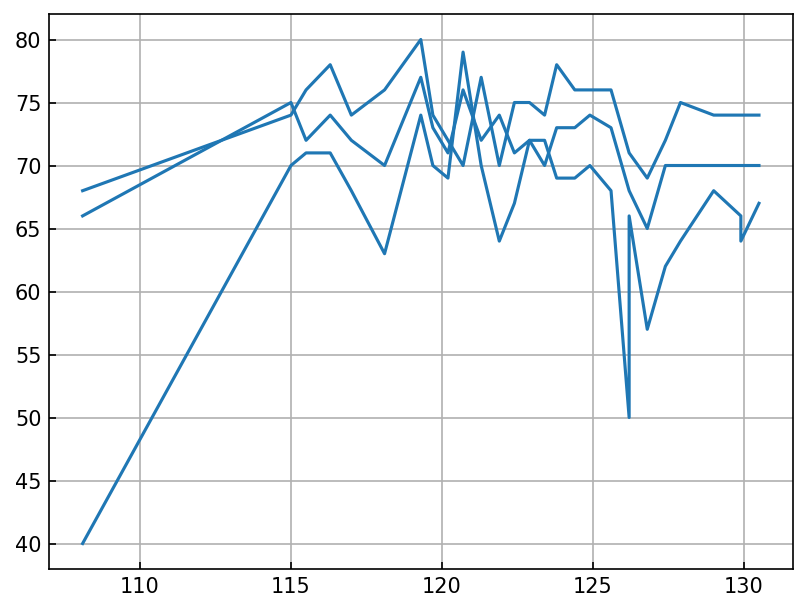

In [241]:
fig, ax = plt.subplots(1, 1)

color = {'n': 'tab:blue', 's': 'red'}
for direction in ['n', 's']:
    sub_df = gdf.loc[direction]
    for lane in sub_df.index.get_level_values(0).unique():
        lane_df = sub_df.loc[lane].sort_values(['linear-reference'])
        ax.plot(lane_df['linear-reference'], lane_df['vehicle_speed'], color=color[direction])

lane_df

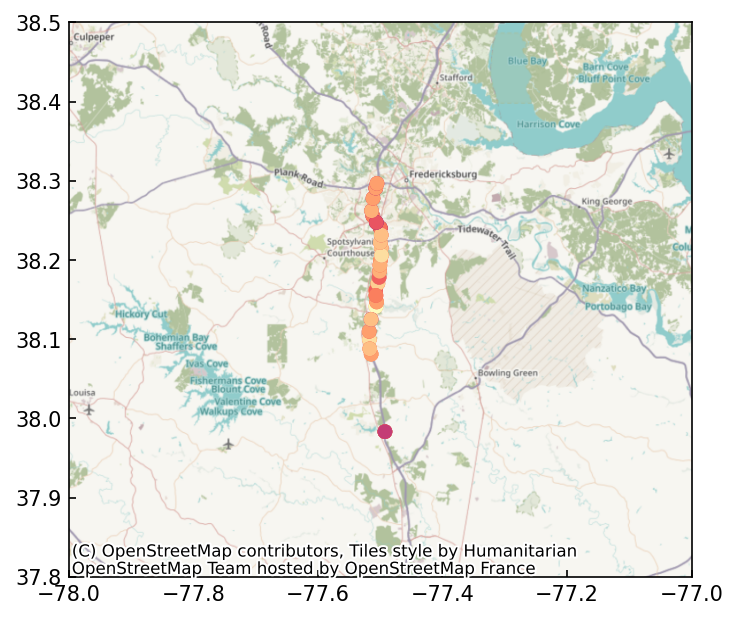

In [244]:
gdf = station_df.merge(sensor_data, on='device-id', how='right')

fig, ax = plt.subplots(1, 1)
gdf.plot('vehicle_speed', ax=ax, cmap='magma', vmin=50, vmax=80)
ax.set(xlim=[-78, -77], ylim=[37.8, 38.5])
cx.add_basemap(ax=ax, crs=station_df.crs)
# ax.set(xticks=[], yticks=[])
ax.grid(False)